In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [7]:
titanic_df = pd.read_csv("titanic_train.csv")
titanic_df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [11]:
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [13]:
titanic_df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [19]:
titanic_df["Age"] = titanic_df["Age"].fillna(titanic_df["Age"].mean())
titanic_df["Cabin"] = titanic_df["Cabin"].fillna("N")
titanic_df["Embarked"] = titanic_df["Embarked"].fillna("N")

print("결측값의 수:", titanic_df.isna().sum().sum())

결측값의 수: 0


In [21]:
print("Sex 값 분포:\n", titanic_df.Sex.value_counts())
print("-"*80)
print("Cabin 값 분포:\n", titanic_df.Cabin.value_counts())
print("-"*80)
print("Embarked 값 분포:\n", titanic_df.Embarked.value_counts())

Sex 값 분포:
 Sex
male      577
female    314
Name: count, dtype: int64
--------------------------------------------------------------------------------
Cabin 값 분포:
 Cabin
N              687
C23 C25 C27      4
G6               4
B96 B98          4
C22 C26          3
              ... 
E34              1
C7               1
C54              1
E36              1
C148             1
Name: count, Length: 148, dtype: int64
--------------------------------------------------------------------------------
Embarked 값 분포:
 Embarked
S    644
C    168
Q     77
N      2
Name: count, dtype: int64


In [23]:
titanic_df["Cabin"] = titanic_df["Cabin"].str[:1]
print("Cabin 값 분포:\n", titanic_df.Cabin.value_counts())

Cabin 값 분포:
 Cabin
N    687
C     59
B     47
D     33
E     32
A     15
F     13
G      4
T      1
Name: count, dtype: int64


In [25]:
titanic_df.groupby(['Sex','Survived'])['Survived'].count()

Sex     Survived
female  0            81
        1           233
male    0           468
        1           109
Name: Survived, dtype: int64

In [31]:
sns.barplot(x='Sex', y = 'Survived', data=titanic_df)

<Axes: xlabel='Sex', ylabel='Survived'>

In [33]:
sns.barplot(x='Pclass', y='Survived', hue='Sex', data=titanic_df)

<Axes: xlabel='Sex', ylabel='Survived'>

In [35]:
# 입력 age에 따라 구분값을 반환하는 함수 설정. DataFrame의 apply lambda식에 사용. 
def get_category(age):
    cat = ''
    if age <= -1: cat = 'Unknown'
    elif age <= 5: cat = 'Baby'
    elif age <= 12: cat = 'Child'
    elif age <= 18: cat = 'Teenager'
    elif age <= 25: cat = 'Student'
    elif age <= 35: cat = 'Young Adult'
    elif age <= 60: cat = 'Adult'
    else : cat = 'Elderly'
    
    return cat

# 막대그래프의 크기 figure를 더 크게 설정 
plt.figure(figsize=(10,6))

#X축의 값을 순차적으로 표시하기 위한 설정 
group_names = ['Unknown', 'Baby', 'Child', 'Teenager', 'Student', 'Young Adult', 'Adult', 'Elderly']

# lambda 식에 위에서 생성한 get_category( ) 함수를 반환값으로 지정. 
# get_category(X)는 입력값으로 'Age' 컬럼값을 받아서 해당하는 cat 반환
titanic_df['Age_cat'] = titanic_df['Age'].apply(lambda x : get_category(x))
sns.barplot(x='Age_cat', y = 'Survived', hue='Sex', data=titanic_df, order=group_names)
titanic_df.drop('Age_cat', axis=1, inplace=True)

In [37]:
from sklearn import preprocessing

def encode_features(dataDF):
    features = ['Cabin', 'Sex', 'Embarked']
    for feature in features:
        le = preprocessing.LabelEncoder()
        le = le.fit(dataDF[feature])
        dataDF[feature] = le.transform(dataDF[feature])
        
    return dataDF

titanic_df = encode_features(titanic_df)
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,7,3
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,2,0
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,7,3
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,2,3
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,7,3


In [43]:
from sklearn.preprocessing import LabelEncoder

# Null 처리 함수
def fillna(df):
    df['Age'].fillna(df['Age'].mean(), inplace=True)
    df['Cabin'].fillna('N', inplace=True)
    df['Embarked'].fillna('N', inplace=True)
    df['Fare'].fillna(0, inplace=True)
    return df

# 머신러닝 알고리즘에 불필요한 피처 제거
def drop_features(df):
    df.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)
    return df

# 레이블 인코딩 수행.
def format_features(df):
    df['Cabin'] = df['Cabin'].str[:1]
    features = ['Cabin', 'Sex', 'Embarked']
    for feature in features:
        le = LabelEncoder()
        le = le.fit(df[feature])
        df[feature] = le.transform(df[feature])
    return df

In [73]:
# 원본 데이터를 재로딩하고, feature 데이터 셋과 Label 데이터 셋 추출.
titanic_df = pd.read_csv('./titanic_train.csv')
y_titanic_df = titanic_df['Survived']
X_titanic_df = titanic_df.drop('Survived', axis=1)

# transform_features 함수 내에서 inplace 매개변수를 제거하고 새로운 데이터프레임 열에 할당
def transform_features(df):
    df['Age'] = df['Age'].fillna(df['Age'].mean())
    df['Cabin'] = df['Cabin'].fillna('N')
    df['Embarked'] = df['Embarked'].fillna('N')
    df['Fare'] = df['Fare'].fillna(0)

    # 필요 없는 열 제거
    df = df.drop(['Name', 'Ticket'], axis=1)

    # 문자열 변수를 숫자형으로 인코딩
    label_encoder = LabelEncoder()
    for col in ['Cabin', 'Sex', 'Embarked']:
        df[col] = label_encoder.fit_transform(df[col])

    return df


X_titanic_df = transform_features(X_titanic_df)


In [77]:
# 데이터 변환 적용
titanic_df = pd.read_csv('./titanic_train.csv')
y_titanic_df = titanic_df['Survived']
X_titanic_df = titanic_df.drop('Survived', axis=1)
X_titanic_df = transform_features(X_titanic_df)

In [79]:
# 데이터 분할 및 모델 학습
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

X_train, X_test, y_train, y_test = train_test_split(X_titanic_df, y_titanic_df, test_size=0.2, random_state=15)
dt_clf = DecisionTreeClassifier()
dt_clf.fit(X_train, y_train)

DecisionTreeClassifier()

In [83]:
from sklearn.tree import export_graphviz
import warnings
warnings.filterwarnings('ignore')

# 특성 이름 및 클래스 이름 지정
feature_names = X_titanic_df.columns.tolist()
class_names = ['Not Survived', 'Survived']

# export_graphviz()의 호출 결과로 out_file로 지정된 tree.dot 파일을 생성함.
export_graphviz(dt_clf, out_file="titanic_tree.dot", class_names=class_names, \
feature_names=feature_names, impurity=True, filled=True)

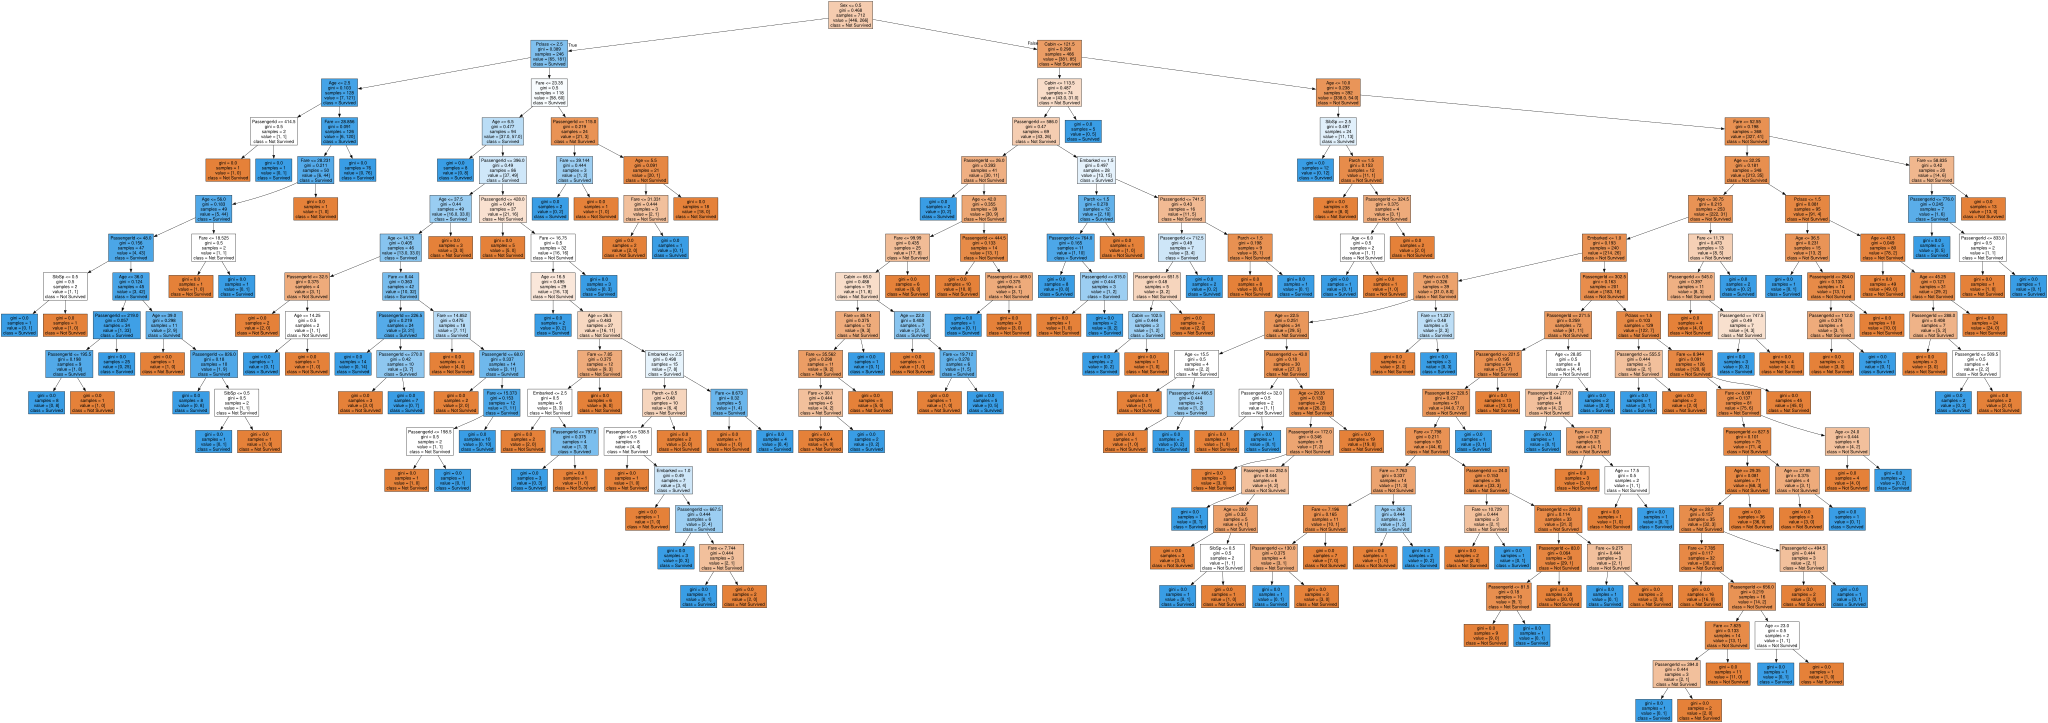

In [87]:
import graphviz

# 위에서 생성된 tree.dot 파일을 Graphviz 읽어서 Jupyter Notebook상에서 시각화 
with open("titanic_tree.dot") as f:
    dot_graph = f.read()
graphviz.Source(dot_graph)

In [89]:
# titanic_df.groupby(["Sex"]).mean()["Survived"]
titanic_df.pivot_table("Survived", "Sex", aggfunc="mean")

,Survived
Sex,
female,0.742038
male,0.188908


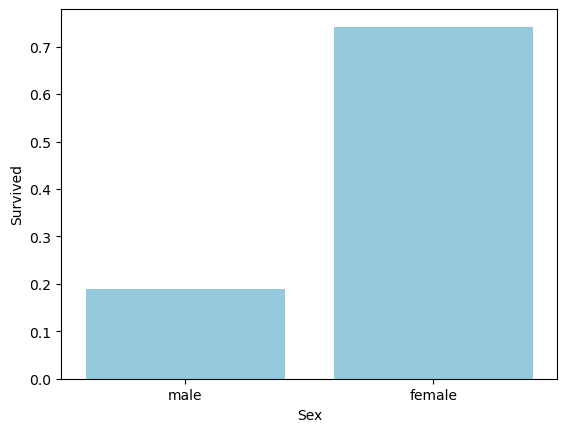

In [103]:
sns.barplot(x = "Sex", y = "Survived", data = titanic_df,
            ci =None, 
            color = "skyblue")
plt.show()

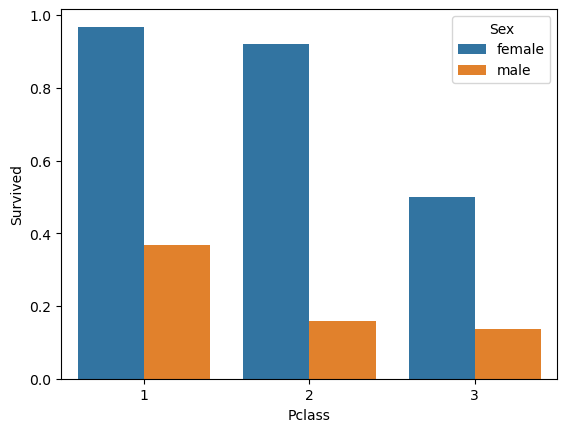

In [101]:
sns.barplot(x = "Pclass", y = "Survived", data = titanic_df,
            ci =None, 
            hue = "Sex")
plt.show()

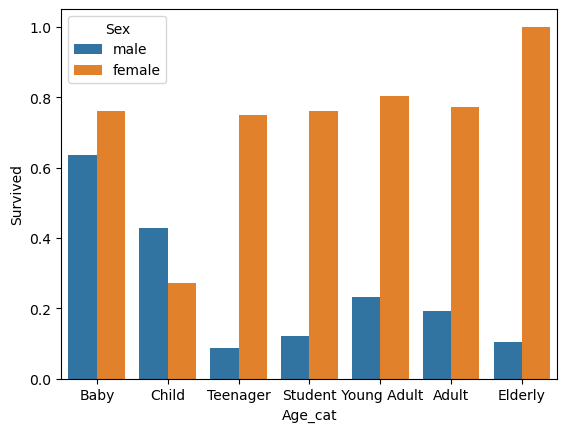

In [105]:
# 나이 그룹 변수 추가
bins = [np.min(titanic_df.Age), 5, 12, 18, 25, 35, 60, np.max(titanic_df.Age)]
labels = ["Baby", "Child", "Teenager", "Student", " Young Adult", "Adult", "Elderly"]

titanic_df["Age_cat"] = pd.cut(titanic_df["Age"], bins, labels=labels)

# 나이 그룹별 생존 확률
sns.barplot(x = "Age_cat", y = "Survived", data = titanic_df,
            ci =None, 
            hue = "Sex")
plt.show()